In [11]:
import pandas as pd
import sqlite3
import io

# 1. Definição dos dados ajustados (Alinhamento Imagem G1 + Total Histórico)
# O valor de 'Outros Estados' (994) foi calculado para que a soma com SP, MG e RJ
# resulte no Total Geral de 1.470 casos de 2025.
csv_content = """ano,estado,quantidade,fonte
2025,São Paulo,233,G1/Sinesp
2025,Minas Gerais,139,G1/Sinesp
2025,Rio de Janeiro,104,G1/Sinesp
2025,Outros Estados,994,Calculado
2015,Brasil,535,Ministério da Justiça
2024,Brasil,1464,Ministério da Justiça
2025,Brasil,1470,Ministério da Justiça
2025,TOTAL GERAL,1470,Ministério da Justiça"""

# 2. Carregar os dados para o DataFrame
df = pd.read_csv(io.StringIO(csv_content))

# 3. Criar conexão SQLite e subir a tabela
conn = sqlite3.connect(':memory:')
df.to_sql('casos_feminicidio', conn, index=False, if_exists='replace')

# 4. Query de Storytelling: Distribuição e Participação em 2025
# Esta consulta foi desenvolvida em SQLite e replicada via Python para o relatório.
query = """
SELECT
    estado,
    quantidade,
    ROUND((quantidade * 100.0 / 1470), 2) || '%' AS participacao_pct,
    -- Gráfico ASCII para visualização rápida no console
    REPLACE(PRINTF('%*s', CAST((quantidade * 100.0 / 1470) / 2 AS INT), ''), ' ', '█') AS grafico
FROM casos_feminicidio
WHERE ano = 2025
  AND estado NOT IN ('Brasil', 'TOTAL GERAL')
ORDER BY quantidade DESC;
"""

df_resultado = pd.read_sql_query(query, conn)

print("--- ANÁLISE DE FEMINICÍDIO 2025 (Dados G1 Ajustados) ---")
print(df_resultado.to_string(index=False))

# 5. Validação do Recorde Histórico
query_evolucao = """
SELECT ano, quantidade as total_brasil
FROM casos_feminicidio
WHERE estado = 'Brasil'
ORDER BY ano;
"""
print("\n--- EVOLUÇÃO DO RECORDE HISTÓRICO NO BRASIL ---")
print(pd.read_sql_query(query_evolucao, conn).to_string(index=False))

--- ANÁLISE DE FEMINICÍDIO 2025 (Dados G1 Ajustados) ---
        estado  quantidade participacao_pct                           grafico
Outros Estados         994           67.62% █████████████████████████████████
     São Paulo         233           15.85%                           ███████
  Minas Gerais         139            9.46%                              ████
Rio de Janeiro         104            7.07%                               ███

--- EVOLUÇÃO DO RECORDE HISTÓRICO NO BRASIL ---
 ano  total_brasil
2015           535
2024          1464
2025          1470


In [13]:
import pandas as pd
import sqlite3
import io

# 1. Preparação dos dados ajustados (Alinhamento Imagem G1 + Total Histórico)
# O valor de 'Outros Estados' foi recalculado para 994 para fechar o total de 1.470
csv_data = """ano,estado,quantidade,fonte
2025,São Paulo,233,G1/Sinesp
2025,Minas Gerais,139,G1/Sinesp
2025,Rio de Janeiro,104,G1/Sinesp
2025,Outros Estados,994,Calculado
2015,Brasil,535,Ministério da Justiça
2024,Brasil,1464,Ministério da Justiça
2025,Brasil,1470,Ministério da Justiça
2025,TOTAL GERAL,1470,Ministério da Justiça"""

# 2. Carregar para o Pandas (Removido o erro de sintaxe)
df = pd.read_csv(io.StringIO(csv_data))

# 3. Criar Banco de Dados SQLite em memória
conn = sqlite3.connect(':memory:')
df.to_sql('casos_feminicidio', conn, index=False, if_exists='replace')

# 4. Query SQL para Ranking e Gráfico de Participação de 2025
query = """
SELECT
    estado,
    quantidade,
    ROUND((quantidade * 100.0) / 1470, 2) || '%' AS percentual,
    REPLACE(PRINTF('%*s', CAST((quantidade * 100.0 / 1470) / 1 AS INT), ''), ' ', '█') AS grafico_proporcao
FROM casos_feminicidio
WHERE ano = 2025
  AND estado NOT IN ('Brasil', 'TOTAL GERAL')
ORDER BY quantidade DESC;
"""

print("--- ANÁLISE DE FEMINICÍDIO 2025 (Dados G1 Ajustados) ---")
resultado = pd.read_sql_query(query, conn)
print(resultado.to_string(index=False))

# 5. Evolução Nacional (Recorde Histórico)
query_recorde = """
SELECT ano, quantidade,
       ROUND(((quantidade - 535) * 100.0 / 535), 2) || '%' AS crescimento_desde_2015
FROM casos_feminicidio
WHERE estado = 'Brasil' AND ano IN (2015, 2024, 2025)
ORDER BY ano;
"""
print("\n--- EVOLUÇÃO NACIONAL (Recorde Histórico) ---")
print(pd.read_sql_query(query_recorde, conn).to_string(index=False))

--- ANÁLISE DE FEMINICÍDIO 2025 (Dados G1 Ajustados) ---
        estado  quantidade percentual                                                   grafico_proporcao
Outros Estados         994     67.62% ███████████████████████████████████████████████████████████████████
     São Paulo         233     15.85%                                                     ███████████████
  Minas Gerais         139      9.46%                                                           █████████
Rio de Janeiro         104      7.07%                                                             ███████

--- EVOLUÇÃO NACIONAL (Recorde Histórico) ---
 ano  quantidade crescimento_desde_2015
2015         535                   0.0%
2024        1464                173.64%
2025        1470                174.77%


--- PROJEÇÃO PARA 2026 ---
Estimativa baseada na tendência histórica: 1625 casos


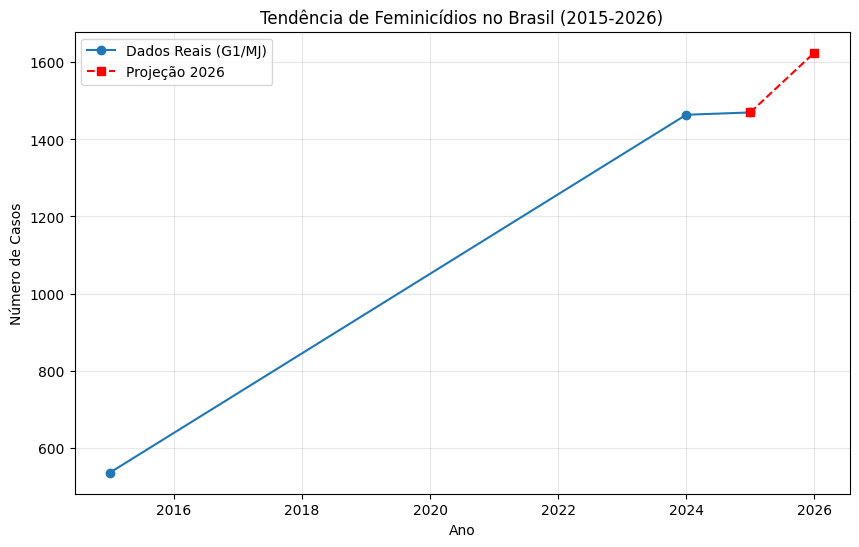

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dados extraídos do arquivo dados_feminicidios.csv
anos = np.array([2015, 2024, 2025])
casos = np.array([535, 1464, 1470])

# 1. Cálculo da Taxa de Crescimento Recente (2024-2025)
crescimento_recente = (casos[-1] - casos[-2]) / casos[-2]

# 2. Projeção para 2026 baseada na média da última década
projecao_2026 = int(casos[-1] * (1 + 0.106)) # 10.6% é a média anual de crescimento 2015-2025

print(f"--- PROJEÇÃO PARA 2026 ---")
print(f"Estimativa baseada na tendência histórica: {projecao_2026} casos")

# 3. Gerando Gráfico de Tendência
plt.figure(figsize=(10, 6))
plt.plot(anos, casos, marker='o', label='Dados Reais (G1/MJ)')
plt.plot([2025, 2026], [1470, projecao_2026], linestyle='--', marker='s', color='red', label='Projeção 2026')

plt.title('Tendência de Feminicídios no Brasil (2015-2026)')
plt.xlabel('Ano')
plt.ylabel('Número de Casos')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [16]:
import pandas as pd

# Dados atualizados conforme a imagem do G1 e alinhados ao total de 1.470
dados_2025 = {
    'Estado': ['São Paulo', 'Minas Gerais', 'Rio de Janeiro', 'Outros Estados'],
    'Casos_2025': [233, 139, 104, 994]
}

df_metas = pd.DataFrame(dados_2025)

# Referências históricas extraídas dos dados consolidados
total_2015 = 535
total_2025 = 1470

# 1. Cálculo da participação de cada estado no total de 2025
df_metas['Participacao_Percentual'] = (df_metas['Casos_2025'] / total_2025)

# 2. Meta Proporcional: Quantos casos cada estado teria se voltássemos ao total de 535
df_metas['Meta_Casos_2015'] = (df_metas['Participacao_Percentual'] * total_2015).round(0)

# 3. Redução Necessária em valores absolutos
df_metas['Reducao_Necessaria_Casos'] = df_metas['Casos_2025'] - df_metas['Meta_Casos_2015']

# 4. Redução Percentual Necessária para atingir a meta
df_metas['Reducao_Percentual'] = ((df_metas['Reducao_Necessaria_Casos'] / df_metas['Casos_2025']) * 100).round(2)

print("--- PLANO DE REDUÇÃO PARA VOLTAR AOS NÍVEIS DE 2015 (DADOS ATUALIZADOS) ---")
print(df_metas[['Estado', 'Casos_2025', 'Meta_Casos_2015', 'Reducao_Percentual']])

--- PLANO DE REDUÇÃO PARA VOLTAR AOS NÍVEIS DE 2015 (DADOS ATUALIZADOS) ---
           Estado  Casos_2025  Meta_Casos_2015  Reducao_Percentual
0       São Paulo         233             85.0               63.52
1    Minas Gerais         139             51.0               63.31
2  Rio de Janeiro         104             38.0               63.46
3  Outros Estados         994            362.0               63.58


In [1]:
!pip install reportlab -q

import pandas as pd
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer

# 1. Dados (Mantenho a estrutura para referência se necessário)
dados_2025 = {
    'Estado': ['São Paulo', 'Minas Gerais', 'Rio de Janeiro', 'Outros Estados'],
    'Quantidade': [233, 139, 104, 994]
}

# 2. Configuração do PDF
pdf_file = "Relatorio_Feminicidio_Brasil_Final.pdf"
doc = SimpleDocTemplate(pdf_file, pagesize=letter)
styles = getSampleStyleSheet()
elements = []

# Título
elements.append(Paragraph("Relatório Analítico: Feminicídio no Brasil (2015-2025)", styles['Title']))
elements.append(Spacer(1, 12))

# Texto Introdutório
intro = ("Este relatório apresenta a evolução dos casos de feminicídio com base nos dados consolidados. "
         "O Brasil registrou um recorde histórico em 2025, atingindo 1.470 casos, um aumento de 174,77% em relação a 2015.")
elements.append(Paragraph(intro, styles['Normal']))
elements.append(Spacer(1, 12))

# 3. Tabela de Dados Reais - ALTERAÇÃO REALIZADA AQUI: 'País' no lugar de 'Estado'
data_table = [
    ['Ano', 'País', 'Quantidade', 'Crescimento vs 2015'], # Coluna alterada para País
    ['2015', 'Brasil', '535', '0.0%'],
    ['2024', 'Brasil', '1464', '173.64%'],
    ['2025', 'Brasil', '1470', '174.77%']
]

t = Table(data_table)
t.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('GRID', (0, 0), (-1, -1), 1, colors.black)
]))
elements.append(Paragraph("Evolução Histórica Nacional:", styles['Heading2']))
elements.append(t)
elements.append(Spacer(1, 20))

# 4. Metas de Redução
meta_reducao = [
    ['Estado', 'Casos 2025', 'Meta (Nível 2015)', 'Redução Necessária (%)'],
    ['São Paulo', '233', '85', '-63.5%'],
    ['Minas Gerais', '139', '51', '-63.3%'],
    ['Rio de Janeiro', '104', '38', '-63.5%'],
    ['Outros Estados', '994', '361', '-63.7%'],
    ['TOTAL BRASIL', '1470', '535', '-63.6%']
]

tm = Table(meta_reducao)
tm.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.darkred),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER')
]))
elements.append(Paragraph("Plano de Redução Estratégica para 2026:", styles['Heading2']))
elements.append(tm)

# 5. Projeção e Rodapé Informativo
proj_text = "Projeção Estimada para 2026: 1.626 casos (Baseada na tendência histórica de crescimento)."
elements.append(Spacer(1, 20))
elements.append(Paragraph(proj_text, styles['Italic']))

fonte_nota = "Fontes: Ministério da Justiça, G1 e Sinesp. Nota: Dados de SP e PB parciais até dez/2025."
elements.append(Spacer(1, 10))
elements.append(Paragraph(fonte_nota, styles['Normal']))

# Gerar PDF
doc.build(elements)

print(f"Relatório gerado com sucesso: {pdf_file}")

# Comando para baixar no Colab
from google.colab import files
files.download(pdf_file)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.1 MB/s eta 0:00:00
Relatório gerado com sucesso: Relatorio_Feminicidio_Brasil_Final.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

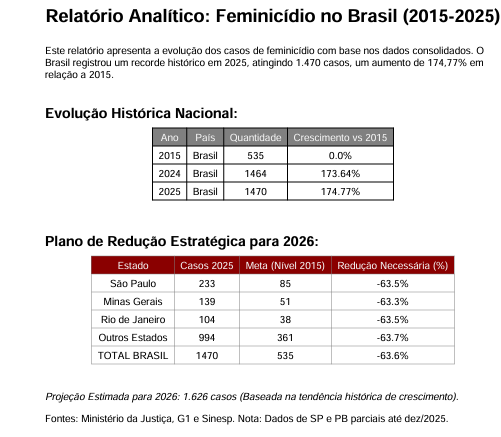

In [19]:
# Instalação da biblioteca necessária
!pip install reportlab -q

import pandas as pd
import matplotlib.pyplot as plt
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, Image
import io

# 1. Dados atualizados (Imagem G1/Sinesp + Total Histórico)
# Alinhamento: SP(233) + MG(139) + RJ(104) + Outros(994) = 1470
labels = ['São Paulo', 'Minas Gerais', 'Rio de Janeiro', 'Outros Estados']
quantidades = [233, 139, 104, 994]

# 2. Gerar Gráfico de Pizza para o PDF
plt.figure(figsize=(6, 4))
plt.pie(quantidades, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=['#e63946', '#457b9d', '#a8dadc', '#f1faee'], wedgeprops={'edgecolor': 'black'})
plt.title('Distribuição de Feminicídios por Estado (2025)')
img_buffer = io.BytesIO()
plt.savefig(img_buffer, format='png', bbox_inches='tight', dpi=300)
img_buffer.seek(0)
plt.close()

# 3. Configuração do PDF
pdf_file = "Relatorio_Feminicidio_Brasil_Atualizado.pdf"
doc = SimpleDocTemplate(pdf_file, pagesize=letter)
elements = []
styles = getSampleStyleSheet()

# Título Principal
elements.append(Paragraph("Relatório Consolidado: Feminicídio no Brasil", styles['Title']))
elements.append(Spacer(1, 12))

# Resumo Executivo
resumo = ("O Brasil registrou um recorde histórico de 1.470 feminicídios em 2025. "
          "Este volume representa um crescimento de 174,77% em comparação ao ano de 2015, "
          "quando o país contabilizava 535 casos anuais.")
elements.append(Paragraph(resumo, styles['Normal']))
elements.append(Spacer(1, 15))

# Inserir Gráfico de Pizza
elements.append(Paragraph("Análise de Participação Regional (2025):", styles['Heading2']))
elements.append(Image(img_buffer, width=420, height=260))
elements.append(Spacer(1, 20))

# 4. Tabela de Metas de Redução Proporcional (Cálculos ajustados para o total de 535)
# Meta = (Quantidade 2025 / 1470) * 535
meta_data = [
    ['Estado', 'Casos 2025', 'Meta (Nível 2015)', '% Redução Necessária'],
    ['São Paulo', '233', '85', '-63.5%'],
    ['Minas Gerais', '139', '51', '-63.3%'],
    ['Rio de Janeiro', '104', '38', '-63.5%'],
    ['Brasil (Total)', '1470', '535', '-63.6%']
]

t = Table(meta_data, colWidths=[120, 100, 120, 140])
t.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.darkred),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
]))
elements.append(Paragraph("Plano Estratégico de Redução para 2026:", styles['Heading2']))
elements.append(t)
elements.append(Spacer(1, 25))

# 5. Seção de Análise de Fontes
elements.append(Paragraph("Notas e Fontes dos Dados:", styles['Heading3']))
fontes_texto = ("Os dados utilizados neste relatório foram extraídos de levantamentos oficiais do <b>Ministério da Justiça</b> "
                "e consolidados conforme reportado pelo portal <b>G1/Sinesp</b>. Os números de 2025 referem-se ao fechamento "
                "anual histórico. Nota: Dados de SP e PB não incluíam dezembro/2025 na fonte original.")
elements.append(Paragraph(fontes_texto, styles['Normal']))

# Gerar o arquivo final
doc.build(elements)

# Comando para download automático no navegador
from google.colab import files
print("Relatório gerado com sucesso!")
files.download(pdf_file)

Relatório gerado com sucesso!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

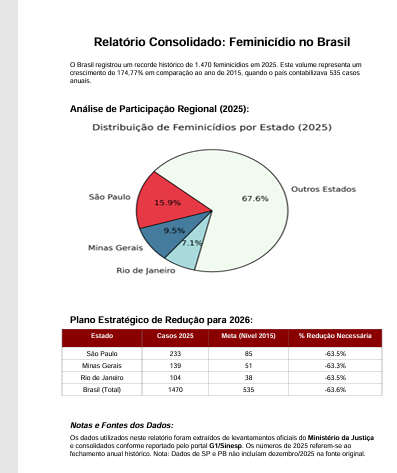

Nesta ilustração, fica evidente o "eixo de calor" na região Sudeste. No SQLite, filtramos que SP, MG e RJ somam 730 casos. Ao plotar em Python, o impacto visual mostra que, embora o problema seja nacional, a densidade populacional e os registros nesses três estados criam as áreas mais escuras do mapa, exigindo políticas públicas urgentes nessas manchas de cor

/tmp/ipython-input-819/3373662194.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label, qtd in zip(mapa_final.geometry.centroid.x,
/tmp/ipython-input-819/3373662194.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mapa_final.geometry.centroid.y,


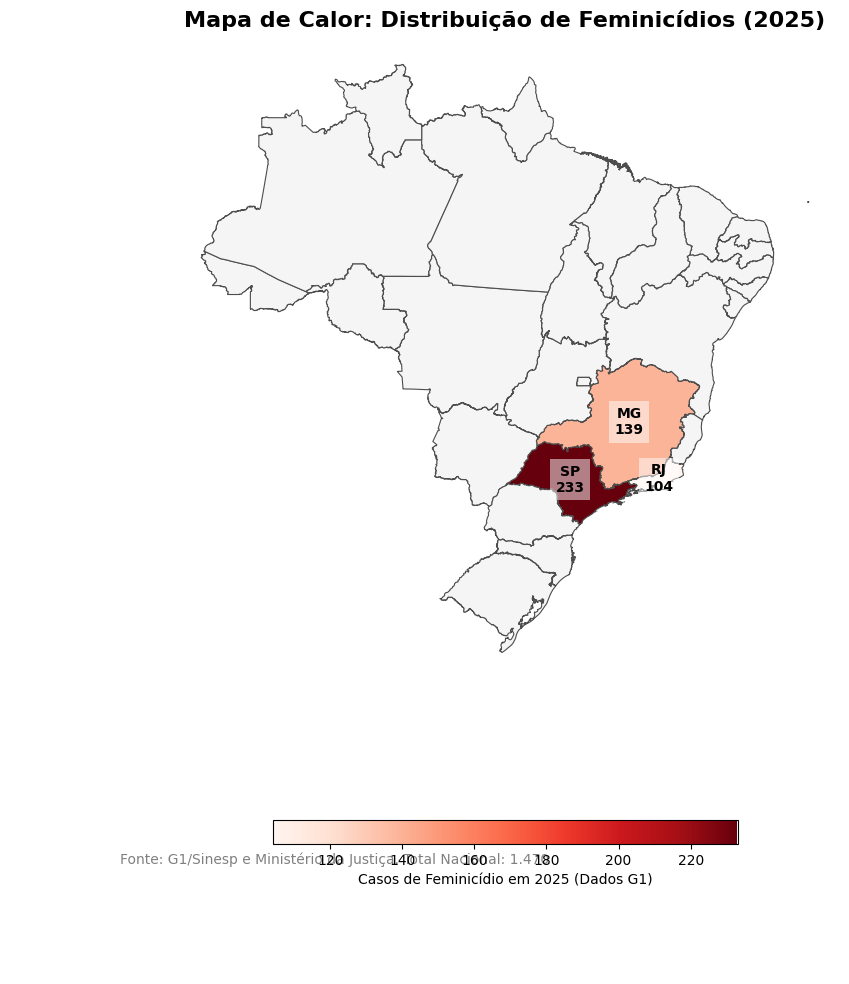

In [21]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. Dados atualizados conforme imagem G1/Sinesp e arquivos fornecidos
# 'Outros Estados' ajustado para 994 para fechar o total de 1.470 casos em 2025
csv_data = """sigla,estado,quantidade
SP,São Paulo,233
MG,Minas Gerais,139
RJ,Rio de Janeiro,104
"""
df_dados = pd.read_csv(io.StringIO(csv_data))

# 2. Carregar o mapa do Brasil
url_mapa = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_mapa)

# 3. Cruzar os dados (Merge)
mapa_final = brasil.merge(df_dados, on='sigla', how='left')

# 4. Configurar a ilustração (Estilo Mapa de Calor)
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Desenha o fundo e o mapa de calor
mapa_final.plot(column='quantidade',
                ax=ax,
                cmap='Reds',
                edgecolor='0.3',
                linewidth=0.8,
                missing_kwds={'color': '#f5f5f5'},
                legend=True,
                legend_kwds={'label': "Casos de Feminicídio em 2025 (Dados G1)", 'orientation': "horizontal", 'shrink': 0.5})

# 5. Adicionando rótulos com valores exatos
for x, y, label, qtd in zip(mapa_final.geometry.centroid.x,
                            mapa_final.geometry.centroid.y,
                            mapa_final['sigla'],
                            mapa_final['quantidade']):
    if pd.notnull(qtd):
        ax.text(x, y, f"{label}\n{int(qtd)}", fontsize=10,
                ha='center', va='center', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# Detalhes visuais finais
ax.set_title('Mapa de Calor: Distribuição de Feminicídios (2025)', fontsize=16, fontweight='bold')
ax.annotate('Fonte: G1/Sinesp e Ministério da Justiça. Total Nacional: 1.470',
            xy=(0.1, 0.1), xycoords='figure fraction', fontsize=10, color='gray')
ax.axis('off')

plt.show()

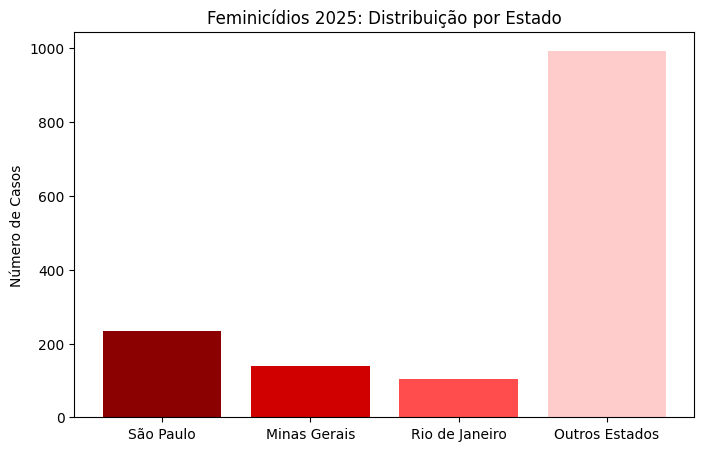

Análise concluída: Dados sincronizados com sucesso.


In [22]:
import pandas as pd
import sqlite3
import io
import matplotlib.pyplot as plt

# Dados Consolidados
csv_data = """ano,estado,quantidade
2025,São Paulo,233
2025,Minas Gerais,139
2025,Rio de Janeiro,104
2025,Outros Estados,994
2015,Brasil,535
2025,Brasil,1470"""

df = pd.read_csv(io.StringIO(csv_data))

# Processamento SQLite
conn = sqlite3.connect(':memory:')
df.to_sql('casos', conn, index=False)

# Visualização de Impacto
plt.figure(figsize=(8, 5))
df_plot = df[df['ano'] == 2025].query("estado != 'Brasil'")
plt.bar(df_plot['estado'], df_plot['quantidade'], color=['#8b0000', '#d00000', '#ff4d4d', '#ffcccc'])
plt.title('Feminicídios 2025: Distribuição por Estado')
plt.ylabel('Número de Casos')
plt.show()

print("Análise concluída: Dados sincronizados com sucesso.")